
# Electricity Consumption Forecasting Using LSTM

## Project Overview
This project predicts future electricity consumption using **LSTM (Long Short-Term Memory)** based on previous electricity usage data.

The goal is to:
- Reduce energy wastage
- Improve smart energy management
- Understand time-series forecasting using Deep Learning

---

## Concepts Covered
- RNN (Recurrent Neural Network)
- LSTM
- Time-Series Forecasting
- Data Preprocessing
- Sequence Creation
- Model Training
- Prediction Visualization



# Step 1: Import Required Libraries
We first import all the libraries needed for data processing, visualization, and LSTM modeling.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM



# Step 2: Load the Dataset

We load the electricity consumption dataset.


In [3]:

df = pd.read_csv('/home/intellect/Documents/p2project/LSTM project/AEP_hourly.csv')
df.head()


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0



# Step 3: Understand the Dataset

Check dataset structure and missing values.


In [4]:

print(df.shape)
print(df.columns)

df.info()


(121273, 2)
Index(['Datetime', 'AEP_MW'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  str    
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.9 MB


In [5]:
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0



# Step 4: Visualize Electricity Consumption

Plot electricity usage over time.


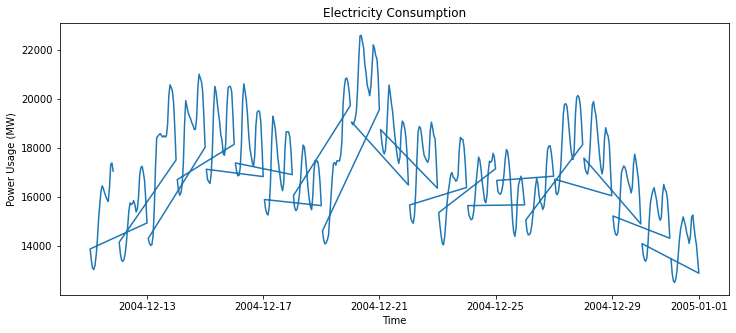

In [6]:

df['Datetime'] = pd.to_datetime(df['Datetime'])

plt.figure(figsize=(12,5))
plt.plot(df['Datetime'][:500], df['AEP_MW'][:500])
plt.title("Electricity Consumption")
plt.xlabel("Time")
plt.ylabel("Power Usage (MW)")
plt.show()


In [7]:
df['Datetime'].head()

0   2004-12-31 01:00:00
1   2004-12-31 02:00:00
2   2004-12-31 03:00:00
3   2004-12-31 04:00:00
4   2004-12-31 05:00:00
Name: Datetime, dtype: datetime64[us]


# Step 5: Data Preprocessing

Normalize the electricity consumption values between 0 and 1.


In [8]:

data = df['AEP_MW'].values.reshape(-1,1)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

scaled_data[:5]


array([[0.24183939],
       [0.20379794],
       [0.18592528],
       [0.18220181],
       [0.19169666]])


# Step 6: Create Sequences for LSTM

LSTM learns from previous values to predict future values.

Here:
- Previous 24 values = Input
- Next value = Output


In [9]:

X = []
y = []

time_step = 24

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)
print(y.shape)


(121249, 24, 1)
(121249,)



# Step 7: Split Dataset

Split the data into training and testing sets.


In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)


(96999, 24, 1)
(24250, 24, 1)



# Step 8: Build the LSTM Model

The model contains:
- One LSTM layer
- One Dense output layer


In [11]:

model = Sequential()

model.add(LSTM(50, activation='relu', input_shape=(X.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()


/home/intellect/Documents/p2project/tfenv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


# Step 9: Train the Model


In [12]:

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/5
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0023 - val_loss: 8.4501e-04
Epoch 2/5
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 6.8954e-04 - val_loss: 8.1213e-04
Epoch 3/5
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 6.5195e-04 - val_loss: 7.0139e-04
Epoch 4/5
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 6.1201e-04 - val_loss: 5.5878e-04
Epoch 5/5
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 5.7154e-04 - val_loss: 5.5623e-04



# Step 10: Make Predictions


In [13]:

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
actual = scaler.inverse_transform(y_test.reshape(-1,1))


758/758 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step



# Step 11: Compare Actual vs Predicted Values


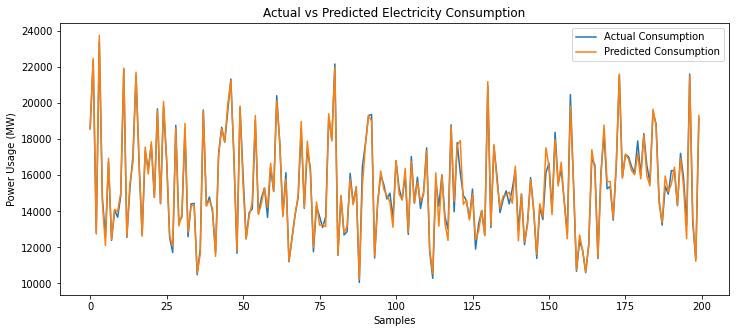

In [14]:

plt.figure(figsize=(12,5))

plt.plot(actual[:200], label='Actual Consumption')
plt.plot(predictions[:200], label='Predicted Consumption')

plt.title("Actual vs Predicted Electricity Consumption")
plt.xlabel("Samples")
plt.ylabel("Power Usage (MW)")
plt.legend()

plt.show()



# Conclusion

In this project, we:
- Used electricity consumption data
- Applied preprocessing and normalization
- Built an LSTM model
- Predicted future electricity consumption

This project demonstrates how Deep Learning can be used for smart energy forecasting and efficient energy management.
